In [ ]:
# Import required libraries and dependencies
import pandas as pd
import hvplot.pandas
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [47]:
# Load the data into a Pandas DataFrame
# df_market_data = pd.read_csv(
#     "Resources/crypto_market_data.csv",
#     index_col="coin_id")

# # Display sample data
# df_market_data.head(10)

In [ ]:
# Load the data into a Pandas DataFrame
df_market_data = pd.read_csv("Resources/crypto_market_data.csv")
#not using the one with the coin_id index to make it easier down the road for the scaling

# Display sample data
df_market_data.head(15)

,coin_id,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
0,bitcoin,1.08388,7.60278,6.57509,7.67258,-3.25185,83.51840,37.51761
1,ethereum,0.22392,10.38134,4.80849,0.13169,-12.88890,186.77418,101.96023
2,tether,-0.21173,0.04935,0.00640,-0.04237,0.28037,-0.00542,0.01954
3,ripple,-0.37819,-0.60926,2.24984,0.23455,-17.55245,39.53888,-16.60193
4,bitcoin-cash,2.90585,17.09717,14.75334,15.74903,-13.71793,21.66042,14.49384
5,binancecoin,2.10423,12.85511,6.80688,0.05865,36.33486,155.61937,69.69195
6,chainlink,-0.23935,20.69459,9.30098,-11.21747,-43.69522,403.22917,325.13186
7,cardano,0.00322,13.99302,5.55476,10.10553,-22.84776,264.51418,156.09756
8,litecoin,-0.06341,6.60221,7.28931,1.21662,-17.23960,27.49919,-12.66408
9,bitcoin-cash-sv,0.92530,3.29641,-1.86656,2.88926,-24.87434,7.42562,93.73082


In [49]:
# Generate summary statistics
df_market_data.describe()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,-0.269686,4.497147,0.185787,1.545693,-0.094119,236.537432,347.667956
std,2.694793,6.375218,8.376939,26.344218,47.365803,435.225304,1247.842884
min,-13.527860,-6.094560,-18.158900,-34.705480,-44.822480,-0.392100,-17.567530
25%,-0.608970,0.047260,-5.026620,-10.438470,-25.907990,21.660420,0.406170
50%,-0.063410,3.296410,0.109740,-0.042370,-7.544550,83.905200,69.691950
75%,0.612090,7.602780,5.510740,4.578130,0.657260,216.177610,168.372510
max,4.840330,20.694590,24.239190,140.795700,223.064370,2227.927820,7852.089700


In [50]:
# Plot your data to see what's in your DataFrame
df_market_data.hvplot.line(
    width=800,
    height=400,
    rot=90
)

:NdOverlay   [Variable]
   :Curve   [index]   (value)

---

### Prepare the Data

In [15]:
df_market_data.head()

,coin_id,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
0,bitcoin,1.08388,7.60278,6.57509,7.67258,-3.25185,83.51840,37.51761
1,ethereum,0.22392,10.38134,4.80849,0.13169,-12.88890,186.77418,101.96023
2,tether,-0.21173,0.04935,0.00640,-0.04237,0.28037,-0.00542,0.01954
3,ripple,-0.37819,-0.60926,2.24984,0.23455,-17.55245,39.53888,-16.60193
4,bitcoin-cash,2.90585,17.09717,14.75334,15.74903,-13.71793,21.66042,14.49384


In [51]:
# Use the `StandardScaler()` module from scikit-learn to normalize the data from the CSV file
scaled_df = df_market_data.drop(columns=['coin_id'])
# scaled_df.head()
scaler = StandardScaler().fit_transform(scaled_df)
# scaler

In [52]:
# Create a DataFrame with the scaled data
df_mkt_scaled = pd.DataFrame(scaler, columns=[
    'price_change_percentage_24h', 
    'price_change_percentage_7d', 
    'price_change_percentage_14d', 
    'price_change_percentage_30d', 
    'price_change_percentage_60d', 
    'price_change_percentage_200d', 
    'price_change_percentage_1y'])
# df_mkt_scaled.head()

# Copy the crypto names from the original DataFrame
df_mkt_scaled['coin_id'] = df_market_data['coin_id'].values

# Set the coin_id column as index
df_mkt_scaled.set_index('coin_id', inplace=True)

# Display the scaled DataFrame
df_mkt_scaled.head()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317


In [ ]:
# # Create a DataFrame with the scaled data
# df_mkt_scaled = pd.DataFrame(scaler, columns=[
#     'price_change_percentage_24h', 
#     'price_change_percentage_7d', 
#     'price_change_percentage_14d', 
#     'price_change_percentage_30d', 
#     'price_change_percentage_60d', 
#     'price_change_percentage_200d', 
#     'price_change_percentage_1y'])
# # df_mkt_scaled.head()

# # Copy the crypto names from the original DataFrame
# df_mkt_scaled['coin_id'] = df_market_data['coin_id'].values

# # Set the coin_id column as index
# df_mkt_scaled.set_index('coin_id', inplace=True)

# # Display the scaled DataFrame
# df_mkt_scaled.head()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
0,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637
1,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352
2,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061
3,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546
4,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317


---

### Find the Best Value for k Using the Original Scaled DataFrame.

In [92]:
# Create a list with the number of k-values from 1 to 11
k_values = list(range(1, 11))
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [93]:
# Create an empty list to store the inertia values
inertia = []

# Create a for loop to compute the inertia with each possible value of k
# Inside the loop:
# 1. Create a KMeans model using the loop counter for the n_clusters
# 2. Fit the model to the data using `df_market_data_scaled`
# 3. Append the model.inertia_ to the inertia list
for i in k_values:
    k_model = KMeans(n_clusters=i, random_state=1)
    k_model.fit(df_mkt_scaled)
    inertia.append(k_model.inertia_)

In [94]:
# Create a dictionary with the data to plot the Elbow curve
elbow_data = {
    'k': k_values,
    'inertia': inertia
}

# Create a DataFrame with the data to plot the Elbow curve
elbow_df = pd.DataFrame(elbow_data)
elbow_df

,k,inertia
0,1,287.000000
1,2,212.123342
2,3,165.136752
3,4,79.022435
4,5,66.413051
5,6,61.634088
6,7,46.074467
7,8,43.392694
8,9,32.913223
9,10,30.469111


In [95]:
# Plot a line chart with all the inertia values computed with
# the different values of k to visually identify the optimal value for k.
elbow_df.hvplot.line(
    x="k", 
    y="inertia", 
    title="Elbow Curve", 
    # xticks = k_values
)

:Curve   [k]   (inertia)

#### Answer the following question: 

**Question:** What is the best value for `k`?

**Answer:** 
The best value for k is 4, as that is when it starts to flatten out, aka the 'elbow point'.

---

### Cluster Cryptocurrencies with K-means Using the Original Scaled DataFrame

In [57]:
# Initialize the K-Means model using the best value for k
model = KMeans(n_clusters=4, random_state=1)

In [58]:
# Fit the K-Means model using the scaled DataFrame
model.fit(df_mkt_scaled)

KMeans(n_clusters=4, random_state=1)

In [59]:
# Predict the clusters to group the cryptocurrencies using the scaled DataFrame
prediction = model.predict(df_mkt_scaled)

# Print the resulting array of cluster values.
prediction

array([2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 3, 2, 0, 0, 1, 0, 0, 0, 0],
      dtype=int32)

In [60]:
# Create a copy of the scaled DataFrame
prediction_df = df_mkt_scaled.copy()

In [61]:
# Add a new column to the copy of the scaled DataFrame with the predicted clusters
prediction_df['predicted_clusters'] = prediction

# Display the copy of the scaled DataFrame
prediction_df.head()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y,predicted_clusters
coin_id,,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637,2
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352,2
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061,0
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546,0
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317,2


In [62]:
# Create a scatter plot using hvPlot by setting
# `x="price_change_percentage_24h"` and `y="price_change_percentage_7d"`.
# Color the graph points with the labels found using K-Means and
# add the crypto name in the `hover_cols` parameter to identify
# the cryptocurrency represented by each data point.
prediction_df.hvplot.scatter(
    x="price_change_percentage_24h",
    y="price_change_percentage_7d",
    by="predicted_clusters",
    hover_cols=["coin_id"],
    title="Crypto Market Clusters"
)

:NdOverlay   [predicted_clusters]
   :Scatter   [price_change_percentage_24h]   (price_change_percentage_7d,coin_id)

---

### Optimize Clusters with Principal Component Analysis.

In [63]:
# Create a PCA model instance and set `n_components=3`.
pca = PCA(n_components=3)

In [64]:
# Use the PCA model with `fit_transform` to reduce the original scaled DataFrame
# down to three principal components.
pca_data = pca.fit_transform(df_mkt_scaled)

# View the scaled PCA data 
pca_data #will output the array version


array([[-0.60066733,  0.84276006,  0.46159457],
       [-0.45826071,  0.45846566,  0.95287678],
       [-0.43306981, -0.16812638, -0.64175193],
       [-0.47183495, -0.22266008, -0.47905316],
       [-1.15779997,  2.04120919,  1.85971527],
       [-0.51653377,  1.38837748,  0.80407131],
       [-0.45071134,  0.51769912,  2.84614316],
       [-0.34559977,  0.72943939,  1.47801284],
       [-0.64946792,  0.43216514,  0.60030286],
       [-0.75901394, -0.20119979, -0.21765292],
       [-0.24819846, -1.37625159, -1.46202571],
       [-0.43840762, -0.17533654, -0.6633884 ],
       [-0.69342533, -0.47381462, -0.52759693],
       [ 0.06049915,  2.90940385,  1.49857131],
       [-0.39335243, -0.10819197, -0.01275608],
       [-0.79617564, -0.49440875,  1.08281169],
       [ 0.06407452, -1.26982514, -1.09882928],
       [-0.48901506, -0.73271912, -0.06254323],
       [-0.3062723 ,  0.70341515,  1.71422359],
       [-0.51352775, -0.14280239, -0.65656583],
       [-0.36212044, -0.98691441, -0.728

In [29]:
# View via a DataFrame (my add)
# pca_df = pd.DataFrame(
#     pca_data,
#     columns=["PC1", "PC2", "PC3"],
#     index=df_mkt_scaled.index #to match the scaled df
# )
# pca_df.head()

In [65]:
# Retrieve the explained variance to determine how much information
# can be attributed to each principal component.
pca.explained_variance_ratio_

array([0.3719856 , 0.34700813, 0.17603793])

#### Answer the following question: 

**Question:** What is the total explained variance of the three principal components?

**Answer:** 

In [66]:
# Create a new DataFrame with the PCA data. (created in the previous cell, but will do again)
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2", "PC3"]
)

# Copy the crypto names from the original scaled DataFrame
pca_df["coin_id"] = df_mkt_scaled.index

# Set the coin_id column as index
pca_df.set_index("coin_id", inplace=True)

# Display the scaled PCA DataFrame
pca_df.head()

,PC1,PC2,PC3
coin_id,,,
bitcoin,-0.600667,0.842760,0.461595
ethereum,-0.458261,0.458466,0.952877
tether,-0.433070,-0.168126,-0.641752
ripple,-0.471835,-0.222660,-0.479053
bitcoin-cash,-1.157800,2.041209,1.859715


---

### Find the Best Value for k Using the Scaled PCA DataFrame

In [67]:
# Create a list with the number of k-values from 1 to 11
k_list = list(range(1,11))
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [81]:
# Create an empty list to store the inertia values
inertia_2 = []

# Create a for loop to compute the inertia with each possible value of k
# Inside the loop:
# 1. Create a KMeans model using the loop counter for the n_clusters
# 2. Fit the model to the data using `df_market_data_pca`
# 3. Append the model.inertia_ to the inertia list
for i in k_list:
    k_model = KMeans(n_clusters=i, random_state=1)
    k_model.fit(pca_df)
    inertia_2.append(k_model.inertia_)


In [82]:
# Create a dictionary with the data to plot the Elbow curve
elbow_data_2 = {
    'k_2': k_list,
    'inertia_2': inertia_2
}

# Create a DataFrame with the data to plot the Elbow curve
elbow_2_df = pd.DataFrame(elbow_data_2)
elbow_2_df

,k_2,inertia_2
0,1,256.874086
1,2,182.339530
2,3,135.442408
3,4,49.665497
4,5,38.672582
5,6,34.507577
6,7,23.728365
7,8,18.574523
8,9,15.572672
9,10,11.407667


In [83]:
# Plot a line chart with all the inertia values computed with
# the different values of k to visually identify the optimal value for k.
elbow_2_df.hvplot.line(
    x="k_2", 
    y="inertia_2", 
    title="Elbow Curve"
)

:Curve   [k_2]   (inertia_2)

#### Answer the following questions: 

* **Question:** What is the best value for `k` when using the PCA data?

  * **Answer:** It looks like 4 is still the best k-value, but that said, it seems to be more flat versus the original elbow curve plot created.


* **Question:** Does it differ from the best k value found using the original data?

  * **Answer:** As I mentioned before, not so much as far as the k-value goes, but visually, it's more plateaud after the k-4 value versus the original one. The inertia values are smaller than the original dataset.

### Cluster Cryptocurrencies with K-means Using the Scaled PCA DataFrame

In [86]:
# Initialize the K-Means model using the best value for k
model_2 = KMeans(n_clusters=4, random_state=0)

In [87]:
# Fit the K-Means model using the PCA data
model_2.fit(pca_df)

KMeans(n_clusters=4, random_state=0)

In [88]:
# Predict the clusters to group the cryptocurrencies using the scaled PCA DataFrame
prediction_2 = model_2.predict(pca_df)

# Print the resulting array of cluster values.
prediction_2

array([2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 3, 0, 0, 0, 0],
      dtype=int32)

In [90]:
# Create a copy of the scaled PCA DataFrame
prediction_2_df = pca_df.copy()

# Add a new column to the copy of the PCA DataFrame with the predicted clusters
prediction_2_df['predicted_clusters'] = prediction_2

# Display the copy of the scaled PCA DataFrame
prediction_2_df.head()

,PC1,PC2,PC3,predicted_clusters
coin_id,,,,
bitcoin,-0.600667,0.842760,0.461595,2
ethereum,-0.458261,0.458466,0.952877,2
tether,-0.433070,-0.168126,-0.641752,0
ripple,-0.471835,-0.222660,-0.479053,0
bitcoin-cash,-1.157800,2.041209,1.859715,2


In [99]:
# Create a scatter plot using hvPlot by setting
# `x="PC1"` and `y="PC2"`.
# Color the graph points with the labels found using K-Means and
# add the crypto name in the `hover_cols` parameter to identify
# the cryptocurrency represented by each data point.
prediction_2_df.hvplot.scatter(
    x="PC1",
    y="PC2",
    by="predicted_clusters",
    hover_cols=["coin_id"],
    title="Crypto Market Clusters"
)

:NdOverlay   [predicted_clusters]
   :Scatter   [PC1]   (PC2,coin_id)

### Visualize and Compare the Results

In this section, you will visually analyze the cluster analysis results by contrasting the outcome with and without using the optimization techniques.

In [107]:
# Composite plot to contrast the Elbow curves
elbow_df #first elbow curve
elbow_2_df #PCA elbow curve

#plotting both
original_plot = elbow_df.hvplot.line(
    x="k", 
    y="inertia", 
    title="Original Scaled Data"
)
pca_plot = elbow_2_df.hvplot.line(
    x="k_2", 
    y="inertia_2", 
    title="PCA Scaled Data",
    color="red",
    line_dash="dashed"
)

#composite plot
composite_plot = original_plot + pca_plot
composite_plot.opts(title="Composite Elbow Curve", legend_position='top_left')

:Layout
   .Curve.I  :Curve   [k]   (inertia)
   .Curve.II :Curve   [k_2]   (inertia_2)

In [ ]:
# composite plot (overlaid, my added)
composite_plot = original_plot * pca_plot
composite_plot.opts(
    title="Composite Elbow Curve", 
    legend_position='top_left',
    xlabel="k",
    ylabel="Inertia"
)

:Overlay
   .Curve.I  :Curve   [k]   (inertia)
   .Curve.II :Curve   [k_2]   (inertia_2)

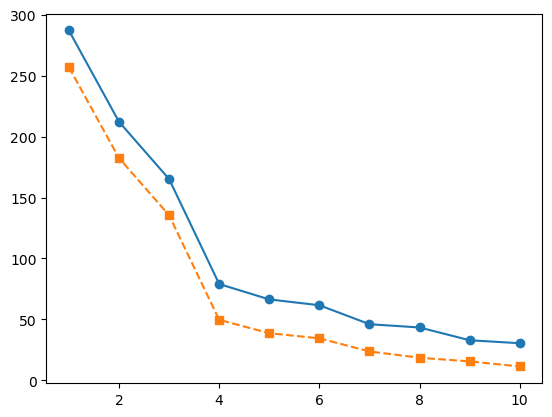

In [ ]:
# Composite plot to contrast the Elbow curves (alternative option)
import matplotlib.pyplot as plt
# k_values = list(range(1,11)) #same range used for both elbow curves
# inertia #inertia df from the first elbow curve
# inertia_2 #inertia df from the second elbow curve

#plotting
plt.plot(k_values, inertia, marker='o', label='Elbow Curve 1')
plt.plot(k_values, inertia_2, marker='s', label='PCA Elbow Curve 2', linestyle='--')


In [111]:
# Composite plot to contrast the clusters

original_cluster_plot = prediction_df.hvplot.scatter(
    x='price_change_percentage_24h',
    y='price_change_percentage_7d',
    by='predicted_clusters',
    hover_cols=['coin_id'],
    title='Clusters from Original Data'
)

pca_cluster_plot = prediction_2_df.hvplot.scatter (
    x='PC1',
    y='PC2',
    by='predicted_clusters',
    hover_cols=['coin_id'],
    title='Clusters from PCA Data'
)

composite_clusters = original_cluster_plot + pca_cluster_plot
composite_clusters

:Layout
   .NdOverlay.I  :NdOverlay   [predicted_clusters]
      :Scatter   [price_change_percentage_24h]   (price_change_percentage_7d,coin_id)
   .NdOverlay.II :NdOverlay   [predicted_clusters]
      :Scatter   [PC1]   (PC2,coin_id)

In [114]:
# composite plot (overlaid, my added)
composite_clusters = original_cluster_plot * pca_cluster_plot
# composite_clusters

#### Answer the following question: 

  * **Question:** After visually analyzing the cluster analysis results, what is the impact of using fewer features to cluster the data using K-Means?

  * **Answer:** It looks like using fewer clusters may omit the outliewrs that the data may have, therefore focusing more on the more saturated range of the data set. Or I guess it's more so like it's been rotated almost 180˚ and zoomed out. At least that's what I'm seeing from the original cluster versus the pca cluster plot.